<a href="https://colab.research.google.com/github/laritrevilato/reconhecimento_de_padroes/blob/main/pattern_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Aqui faz conexão com o meu drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [ ]:
caminho_arquivo = '/content/drive/MyDrive/dados_docentes/DM_DOCENTE.CSV'
df_docentes = pd.read_csv(caminho_arquivo, sep='|', encoding='latin1', low_memory=False)
display(df_docentes.head())

,NU_ANO_CENSO,CO_IES,TP_CATEGORIA_ADMINISTRATIVA,TP_ORGANIZACAO_ACADEMICA,CO_DOCENTE_IES,ID_DOCENTE,TP_SITUACAO,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,TP_SEXO,...,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,IN_BOLSA_PESQUISA,IN_SUBSTITUTO,IN_EXERCICIO_DATA_REFERENCIA,IN_VISITANTE,TP_VISITANTE_IFES_VINCULO
0,2018,1,1,1,1179048,F3CE8D201F9DBA7935A31AC6C8FEF33F,1,5,2.0,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN
1,2018,1,1,1,1179049,7CA2AB18D3383AF3168DCD3D4964D1F5,1,5,1.0,2,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,NaN
2,2018,1,1,1,1179047,8EC22FF9220CDD6A859E555F43B20ED3,1,4,1.0,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
3,2018,1,1,1,1179050,4C47B46F22C91D5F0A2C5D8C61F58259,1,3,1.0,2,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
4,2018,1,1,1,1180953,17EB5D7EF21895C148B654225CF82235,1,5,1.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN


In [ ]:
#aqui estou selecionando as colunas relevantes que vou usar e fazendo um sub dataset só com essas colunas

cols_demograficas = ["NU_IDADE", "TP_SEXO", "TP_COR_RACA"]
cols_formacao_regime = ["TP_ESCOLARIDADE", "TP_REGIME_TRABALHO"]
cols_deficiencia = ["IN_DEFICIENCIA"]
cols_atuacao = [
    "IN_ATUACAO_EAD",
    "IN_ATUACAO_EXTENSAO",
    "IN_ATUACAO_GESTAO",
    "IN_ATUACAO_GRAD_PRESENCIAL",
    "IN_ATUACAO_POS_EAD",
    "IN_ATUACAO_POS_PRESENCIAL",
    "IN_ATUACAO_SEQUENCIAL",
    "IN_ATUACAO_PESQUISA",
    "IN_BOLSA_PESQUISA",
    "IN_SUBSTITUTO",
]

cols_todas = cols_demograficas + cols_formacao_regime + cols_deficiencia + cols_atuacao

df_sel = df_docentes[cols_todas].copy()
df_sel.head()


,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,IN_DEFICIENCIA,IN_ATUACAO_EAD,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,IN_BOLSA_PESQUISA,IN_SUBSTITUTO
0,61,2,3,5,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,66,2,3,5,1.0,0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2,49,2,3,4,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,63,2,4,3,1.0,0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,53,2,1,5,1.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0


In [ ]:
#aqui eu fiz contagem de valores faltantes em cada coluna (quantos registros de cada coluna tem missing values?)
df_sel.isna().sum()

,0
NU_IDADE,0
TP_SEXO,0
TP_COR_RACA,0
TP_ESCOLARIDADE,0
TP_REGIME_TRABALHO,13419
IN_DEFICIENCIA,0
IN_ATUACAO_EAD,13419
IN_ATUACAO_EXTENSAO,13419
IN_ATUACAO_GESTAO,13419
IN_ATUACAO_GRAD_PRESENCIAL,13419


In [ ]:
# Remover a coluna com muitos missing - retirei a coluna do dataset
df_sel = df_sel.drop(columns=["IN_BOLSA_PESQUISA"])

# Remover linhas com qualquer NaN restante
df_sel = df_sel.dropna()

df_sel.shape

(384474, 15)

In [ ]:
#aqui eu separei as colunas por tipos - as que são numéricas, categóricas e binárias.
numeric_features = ["NU_IDADE"]
categorical_features = ["TP_SEXO", "TP_COR_RACA", "TP_ESCOLARIDADE", "TP_REGIME_TRABALHO"]
binary_features = [c for c in df_sel.columns if c not in numeric_features + categorical_features]

numeric_features, categorical_features, binary_features


(['NU_IDADE'],
 ['TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLARIDADE', 'TP_REGIME_TRABALHO'],
 ['IN_DEFICIENCIA',
  'IN_ATUACAO_EAD',
  'IN_ATUACAO_EXTENSAO',
  'IN_ATUACAO_GESTAO',
  'IN_ATUACAO_GRAD_PRESENCIAL',
  'IN_ATUACAO_POS_EAD',
  'IN_ATUACAO_POS_PRESENCIAL',
  'IN_ATUACAO_SEQUENCIAL',
  'IN_ATUACAO_PESQUISA',
  'IN_SUBSTITUTO'])

In [ ]:
#aqui aplicamos o pré processamento, fazendo uma transformação nas colunas (normalização etc...)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_prepared = preprocess.fit_transform(df_sel)

X_prepared.shape
#pronto, nessa variável X_prepared contém o dataset pronto para ser usado em qualquer método.

(384474, 29)

In [ ]:
df_sample = df_sel.sample(n=50000, random_state=42)

# índices (labels) do df_sample
idx_labels = df_sample.index

# converter labels em posições (0..N-1) em relação ao df_sel
idx_pos = df_sel.index.get_indexer(idx_labels)

X_sample = X_prepared[idx_pos, :]
X_sample.shape  # deve dar (50000, 29)


(50000, 29)

In [ ]:
ks = range(2, 10)
inertias = []
silhouettes = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_sample, labels)
    silhouettes.append(sil_score)

inertias, silhouettes


([214745.35185604575,
  182506.87737334523,
  167416.64977448774,
  155906.91269195918,
  149878.58974649684,
  145615.41495955165,
  140694.22119347285,
  136917.9300829455],
 [np.float64(0.6979542234899505),
  np.float64(0.21125493420140187),
  np.float64(0.19897636191951656),
  np.float64(0.1887612116182108),
  np.float64(0.18470844620005342),
  np.float64(0.17511806754614725),
  np.float64(0.18008844806275454),
  np.float64(0.12728735791414592)])

In [ ]:
k_final = 3

modelo_kmeans_full = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("cluster", KMeans(n_clusters=k_final, random_state=42, n_init=10)),
    ]
)

modelo_kmeans_full.fit(df_sel)

labels_final = modelo_kmeans_full["cluster"].labels_

df_clusters = df_sel.copy()
df_clusters["cluster"] = labels_final

df_clusters["cluster"].value_counts().sort_index()


,count
cluster,
0,207374
1,40243
2,136857


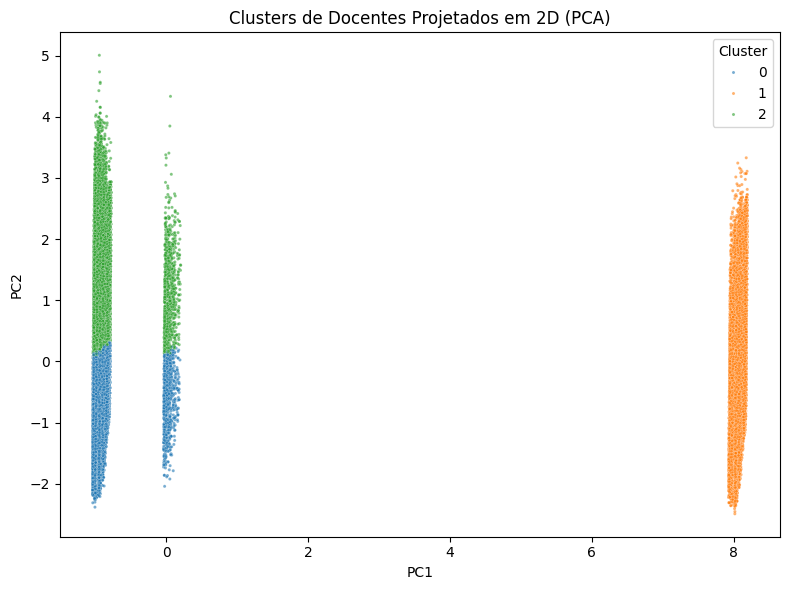

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.decomposition import PCA
# PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(preprocess.fit_transform(df_sel))

df_plot2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_plot2d["cluster"] = labels_final

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_plot2d,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=5,
    alpha=0.6
)
plt.title("Clusters de Docentes Projetados em 2D (PCA)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()
plt.savefig("clusters_pca_kmeans_2d.pdf", bbox_inches="tight")


In [ ]:
df_clusters = df_sel.copy()
df_clusters["cluster"] = labels_final


In [ ]:
df_clusters["cluster"].value_counts().sort_index()


,count
cluster,
0,207374
1,40243
2,136857


In [ ]:
df_clusters.groupby("cluster")["NU_IDADE"].describe()


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,207374.0,37.271114,5.505426,19.0,33.0,37.0,41.0,50.0
1,40243.0,44.908928,11.011869,21.0,36.0,43.0,53.0,87.0
2,136857.0,55.658045,7.150438,42.0,50.0,55.0,60.0,100.0


In [ ]:
df_clusters.groupby("cluster")["TP_SEXO"].value_counts(normalize=True)


cluster  TP_SEXO
0        2          0.500964
         1          0.499036
1        2          0.555674
         1          0.444326
2        2          0.589199
         1          0.410801
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["TP_ESCOLARIDADE"].value_counts(normalize=True)


cluster  TP_ESCOLARIDADE
0        4                  0.471163
         5                  0.313366
         3                  0.204317
         2                  0.011110
         1                  0.000043
1        5                  0.626593
         4                  0.272718
         3                  0.079616
         2                  0.021072
2        5                  0.556515
         4                  0.300262
         3                  0.138561
         2                  0.004596
         1                  0.000066
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["TP_REGIME_TRABALHO"].value_counts(normalize=True)


cluster  TP_REGIME_TRABALHO
0        3.0                   0.328185
         2.0                   0.228896
         1.0                   0.226398
         4.0                   0.216522
1        1.0                   0.638844
         3.0                   0.154934
         2.0                   0.149989
         4.0                   0.056233
2        1.0                   0.366448
         3.0                   0.246622
         2.0                   0.231198
         4.0                   0.155732
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_DEFICIENCIA"].value_counts(normalize=True)


cluster  IN_DEFICIENCIA
0        0                 0.996311
         1                 0.003689
1        9                 1.000000
2        0                 0.993497
         1                 0.006503
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_EAD"].value_counts(normalize=True)


cluster  IN_ATUACAO_EAD
0        0.0               0.951696
         1.0               0.048304
1        0.0               0.962304
         1.0               0.037696
2        0.0               0.942159
         1.0               0.057841
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["NU_IDADE"].describe()


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,207374.0,37.271114,5.505426,19.0,33.0,37.0,41.0,50.0
1,40243.0,44.908928,11.011869,21.0,36.0,43.0,53.0,87.0
2,136857.0,55.658045,7.150438,42.0,50.0,55.0,60.0,100.0


In [ ]:
df_clusters.groupby("cluster")["TP_ESCOLARIDADE"].value_counts(normalize=True)

cluster  TP_ESCOLARIDADE
0        4                  0.471163
         5                  0.313366
         3                  0.204317
         2                  0.011110
         1                  0.000043
1        5                  0.626593
         4                  0.272718
         3                  0.079616
         2                  0.021072
2        5                  0.556515
         4                  0.300262
         3                  0.138561
         2                  0.004596
         1                  0.000066
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["TP_REGIME_TRABALHO"].value_counts(normalize=True)

cluster  TP_REGIME_TRABALHO
0        3.0                   0.328185
         2.0                   0.228896
         1.0                   0.226398
         4.0                   0.216522
1        1.0                   0.638844
         3.0                   0.154934
         2.0                   0.149989
         4.0                   0.056233
2        1.0                   0.366448
         3.0                   0.246622
         2.0                   0.231198
         4.0                   0.155732
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_PESQUISA"].value_counts(normalize=True)


cluster  IN_ATUACAO_PESQUISA
0        0.0                    0.751030
         1.0                    0.248970
1        0.0                    0.607932
         1.0                    0.392068
2        0.0                    0.619267
         1.0                    0.380733
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_GRAD_PRESENCIAL"].value_counts(normalize=True)


cluster  IN_ATUACAO_GRAD_PRESENCIAL
0        1.0                           0.965550
         0.0                           0.034450
1        1.0                           0.950600
         0.0                           0.049400
2        1.0                           0.952206
         0.0                           0.047794
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_POS_PRESENCIAL"].value_counts(normalize=True)


cluster  IN_ATUACAO_POS_PRESENCIAL
0        0.0                          0.919754
         1.0                          0.080246
1        0.0                          0.711801
         1.0                          0.288199
2        0.0                          0.784732
         1.0                          0.215268
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["TP_SEXO"].value_counts(normalize=True)


cluster  TP_SEXO
0        2          0.500964
         1          0.499036
1        2          0.555674
         1          0.444326
2        2          0.589199
         1          0.410801
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["TP_COR_RACA"].value_counts(normalize=True)


cluster  TP_COR_RACA
0        1              0.539330
         0              0.243121
         3              0.181344
         2              0.022631
         4              0.009442
         6              0.002932
         5              0.001201
1        0              0.649455
         1              0.256989
         3              0.069677
         2              0.013990
         4              0.007629
         6              0.001242
         5              0.001019
2        1              0.600656
         0              0.259614
         3              0.107835
         2              0.017829
         4              0.011026
         6              0.001600
         5              0.001439
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_DEFICIENCIA"].value_counts(normalize=True)


cluster  IN_DEFICIENCIA
0        0                 0.996311
         1                 0.003689
1        9                 1.000000
2        0                 0.993497
         1                 0.006503
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_EXTENSAO"].value_counts(normalize=True)


cluster  IN_ATUACAO_EXTENSAO
0        0.0                    0.741728
         1.0                    0.258272
1        0.0                    0.641279
         1.0                    0.358721
2        0.0                    0.693066
         1.0                    0.306934
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_GESTAO"].value_counts(normalize=True)


cluster  IN_ATUACAO_GESTAO
0        0.0                  0.783618
         1.0                  0.216382
1        0.0                  0.695972
         1.0                  0.304028
2        0.0                  0.728790
         1.0                  0.271210
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_SEQUENCIAL"].value_counts(normalize=True)


cluster  IN_ATUACAO_SEQUENCIAL
0        0.0                      0.999248
         1.0                      0.000752
1        0.0                      0.999329
         1.0                      0.000671
2        0.0                      0.998663
         1.0                      0.001337
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_PESQUISA"].value_counts(normalize=True)


cluster  IN_ATUACAO_PESQUISA
0        0.0                    0.751030
         1.0                    0.248970
1        0.0                    0.607932
         1.0                    0.392068
2        0.0                    0.619267
         1.0                    0.380733
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_EAD"].value_counts(normalize=True)

cluster  IN_ATUACAO_EAD
0        0.0               0.951696
         1.0               0.048304
1        0.0               0.962304
         1.0               0.037696
2        0.0               0.942159
         1.0               0.057841
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_POS_EAD"].value_counts(normalize=True)


cluster  IN_ATUACAO_POS_EAD
0        0.0                   0.997237
         1.0                   0.002763
1        0.0                   0.999205
         1.0                   0.000795
2        0.0                   0.997041
         1.0                   0.002959
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_POS_PRESENCIAL"].value_counts(normalize=True)


cluster  IN_ATUACAO_POS_PRESENCIAL
0        0.0                          0.919754
         1.0                          0.080246
1        0.0                          0.711801
         1.0                          0.288199
2        0.0                          0.784732
         1.0                          0.215268
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_GRAD_PRESENCIAL"].value_counts(normalize=True)


cluster  IN_ATUACAO_GRAD_PRESENCIAL
0        1.0                           0.965550
         0.0                           0.034450
1        1.0                           0.950600
         0.0                           0.049400
2        1.0                           0.952206
         0.0                           0.047794
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_EAD"].value_counts(normalize=True)


cluster  IN_ATUACAO_EAD
0        0.0               0.951696
         1.0               0.048304
1        0.0               0.962304
         1.0               0.037696
2        0.0               0.942159
         1.0               0.057841
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["IN_ATUACAO_POS_EAD"].value_counts(normalize=True)


cluster  IN_ATUACAO_POS_EAD
0        0.0                   0.997237
         1.0                   0.002763
1        0.0                   0.999205
         1.0                   0.000795
2        0.0                   0.997041
         1.0                   0.002959
Name: proportion, dtype: float64

In [ ]:
df_clusters.groupby("cluster")["TP_SEXO"].value_counts(normalize=True)


cluster  TP_SEXO
0        2          0.500964
         1          0.499036
1        2          0.555674
         1          0.444326
2        2          0.589199
         1          0.410801
Name: proportion, dtype: float64

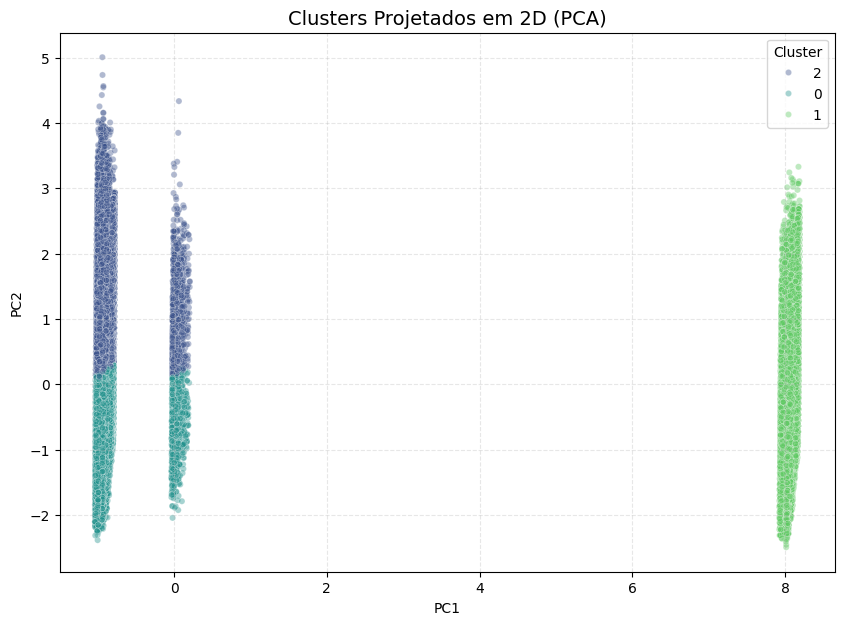

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(modelo_kmeans_full["preprocess"].transform(df_sel))

df_plot2d = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "cluster": df_clusters["cluster"].astype(str)
})

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_plot2d, x="PC1", y="PC2",
    hue="cluster", palette="viridis",
    alpha=0.4, s=20
)
plt.title("Clusters Projetados em 2D (PCA)", fontsize=14)
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


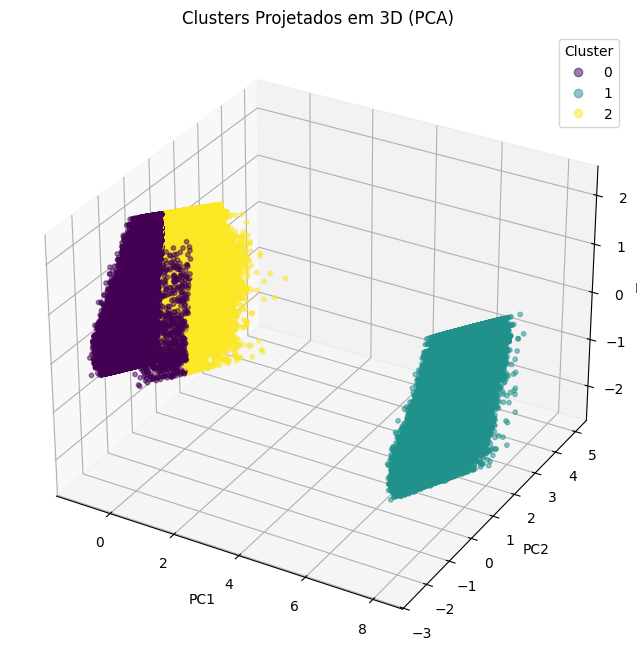

In [ ]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# PCA para 3 componentes
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(modelo_kmeans_full["preprocess"].transform(df_sel))

df_plot3d = pd.DataFrame({
    "PC1": X_pca3[:,0],
    "PC2": X_pca3[:,1],
    "PC3": X_pca3[:,2],
    "cluster": df_clusters["cluster"].astype(str)
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_plot3d["PC1"], df_plot3d["PC2"], df_plot3d["PC3"],
    c=df_plot3d["cluster"].astype(int),
    cmap="viridis", alpha=0.5, s=10
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Clusters Projetados em 3D (PCA)")

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


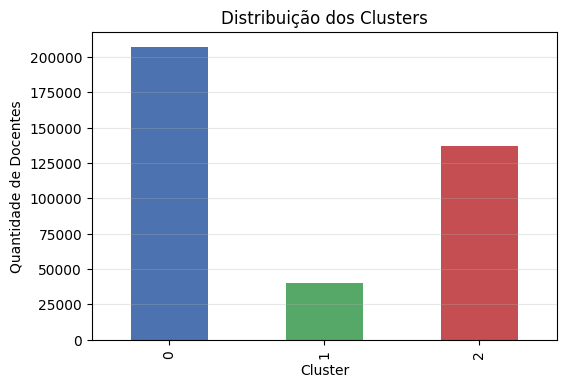

In [ ]:
df_clusters["cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4),
    color=["#4C72B0", "#55A868", "#C44E52"]
)
plt.title("Distribuição dos Clusters")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Docentes")
plt.grid(axis="y", alpha=0.3)
plt.show()


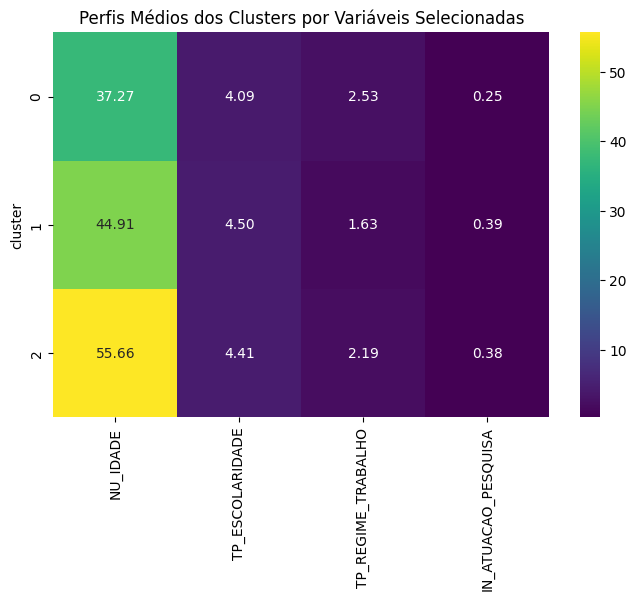

In [ ]:
vars_heatmap = ["NU_IDADE", "TP_ESCOLARIDADE", "TP_REGIME_TRABALHO", "IN_ATUACAO_PESQUISA"]

df_heat = df_clusters.groupby("cluster")[vars_heatmap].mean()

plt.figure(figsize=(8,5))
sns.heatmap(df_heat, annot=True, cmap="viridis", fmt=".2f")
plt.title("Perfis Médios dos Clusters por Variáveis Selecionadas")
plt.show()


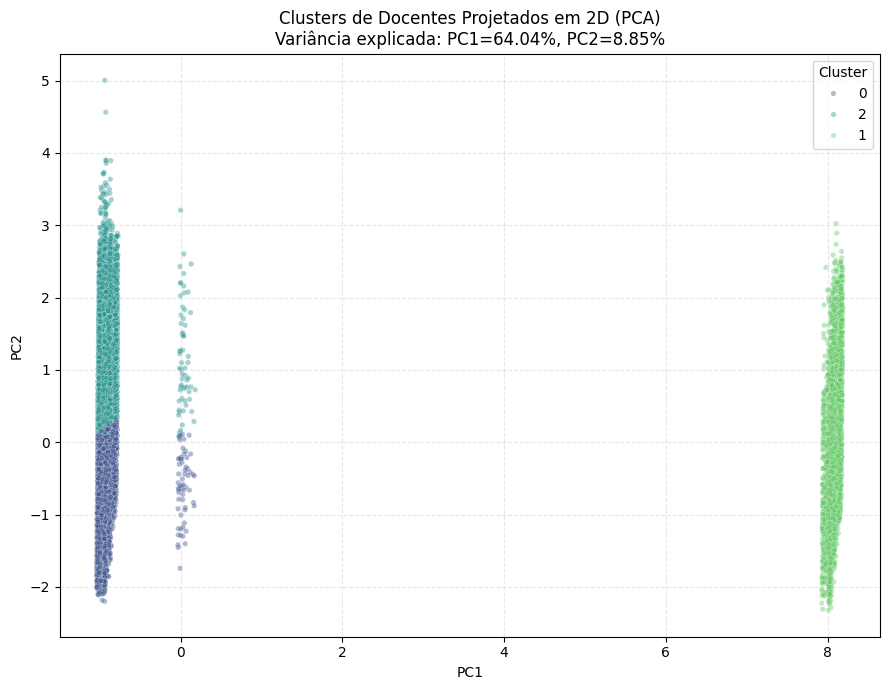

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1) Aplica o mesmo pré-processamento usado no K-means
X_processed = modelo_kmeans_full["preprocess"].transform(df_sel)

# 2) PCA com 2 componentes
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_processed)

# 3) Monta DataFrame para plot
df_pca2 = pd.DataFrame({
    "PC1": X_pca2[:, 0],
    "PC2": X_pca2[:, 1],
    "cluster": df_clusters["cluster"].astype(str)
})

# 4) Amostra (para não plotar 380 mil pontos)
n_amostra = 30000  # você pode ajustar
if len(df_pca2) > n_amostra:
    df_plot2d = df_pca2.sample(n=n_amostra, random_state=42)
else:
    df_plot2d = df_pca2

# 5) Gráfico
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_plot2d,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    alpha=0.4,
    s=15
)

var_exp = pca2.explained_variance_ratio_
plt.title(
    f"Clusters de Docentes Projetados em 2D (PCA)\n"
    f"Variância explicada: PC1={var_exp[0]:.2%}, PC2={var_exp[1]:.2%}"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


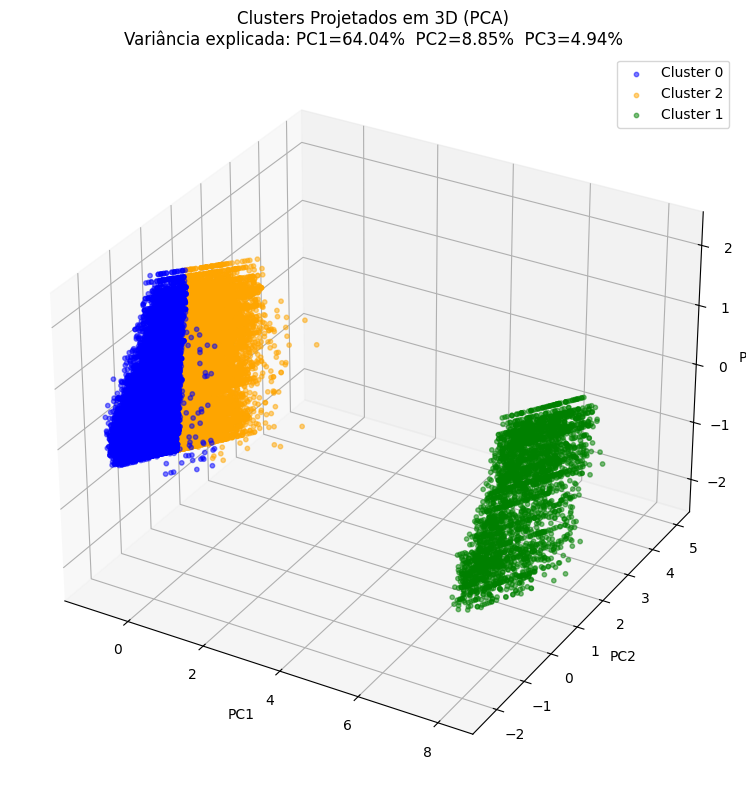

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1) Pré-processamento
X_processed = modelo_kmeans_full["preprocess"].transform(df_sel)

# 2) PCA com 3 componentes
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_processed)

# 3) DataFrame com clusters
df_pca3 = pd.DataFrame({
    "PC1": X_pca3[:, 0],
    "PC2": X_pca3[:, 1],
    "PC3": X_pca3[:, 2],
    "cluster": df_clusters["cluster"].astype(str)
})

# 4) Amostra para visualização
n_amostra = 30000
if len(df_pca3) > n_amostra:
    df_plot3d = df_pca3.sample(n=n_amostra, random_state=42)
else:
    df_plot3d = df_pca3

# 5) Gráfico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

cores = {"0": "blue", "1": "green", "2": "orange"}

for c in df_plot3d["cluster"].unique():
    subset = df_plot3d[df_plot3d["cluster"] == c]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=10,
        alpha=0.5,
        label=f"Cluster {c}",
        color=cores[c]
    )

var = pca3.explained_variance_ratio_
ax.set_title(
    f"Clusters Projetados em 3D (PCA)\n"
    f"Variância explicada: PC1={var[0]:.2%}  PC2={var[1]:.2%}  PC3={var[2]:.2%}"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.tight_layout()
plt.show()


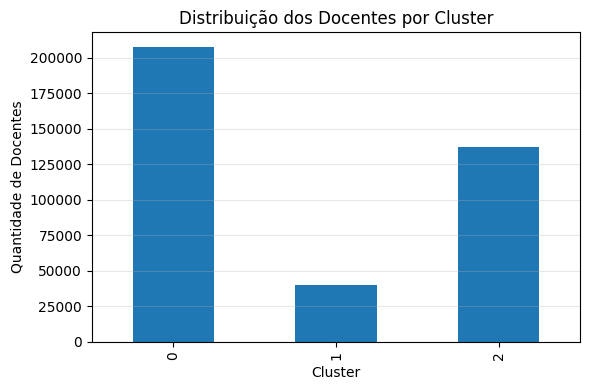

,count
cluster,
0,207374
1,40243
2,136857


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

cluster_counts = df_clusters["cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))
cluster_counts.plot(kind="bar")
plt.title("Distribuição dos Docentes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Docentes")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

cluster_counts


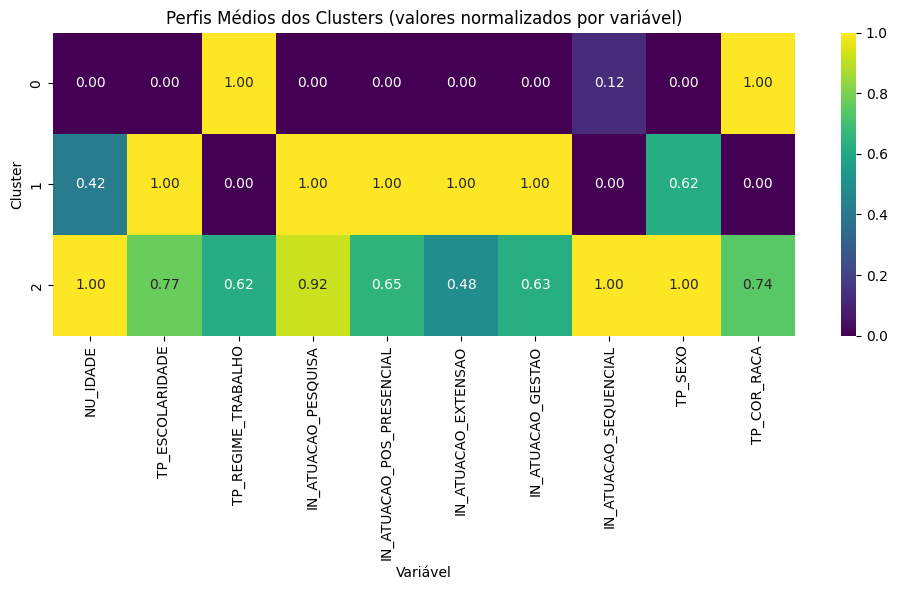

,NU_IDADE,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,IN_ATUACAO_PESQUISA,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_SEQUENCIAL,TP_SEXO,TP_COR_RACA
cluster,,,,,,,,,,
0,37.271114,4.086698,2.534831,0.248970,0.080246,0.258272,0.216382,0.000752,1.500964,1.189985
1,44.908928,4.504833,1.628557,0.392068,0.288199,0.358721,0.304028,0.000671,1.555674,0.537062
2,55.658045,4.408565,2.191638,0.380733,0.215268,0.306934,0.271210,0.001337,1.589199,1.020722


In [ ]:
import seaborn as sns
import numpy as np

# variáveis mais relevantes que vimos juntas
features_heatmap = [
    "NU_IDADE",
    "TP_ESCOLARIDADE",
    "TP_REGIME_TRABALHO",
    "IN_ATUACAO_PESQUISA",
    "IN_ATUACAO_POS_PRESENCIAL",
    "IN_ATUACAO_EXTENSAO",
    "IN_ATUACAO_GESTAO",
    "IN_ATUACAO_SEQUENCIAL",
    "TP_SEXO",
    "TP_COR_RACA",
]

# garante que todas existem
features_heatmap = [c for c in features_heatmap if c in df_clusters.columns]

centroids = df_clusters.groupby("cluster")[features_heatmap].mean()

# normalizar 0–1 por coluna só para visualização
centroids_norm = (centroids - centroids.min()) / (centroids.max() - centroids.min())

plt.figure(figsize=(10,6))
sns.heatmap(
    centroids_norm,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)
plt.title("Perfis Médios dos Clusters (valores normalizados por variável)")
plt.ylabel("Cluster")
plt.xlabel("Variável")
plt.tight_layout()
plt.show()

centroids  # também mostra os valores médios reais


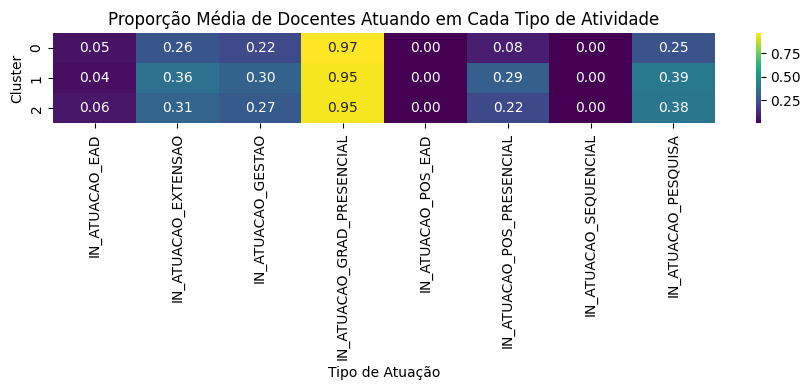

,IN_ATUACAO_EAD,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA
cluster,,,,,,,,
0,0.048304,0.258272,0.216382,0.965550,0.002763,0.080246,0.000752,0.248970
1,0.037696,0.358721,0.304028,0.950600,0.000795,0.288199,0.000671,0.392068
2,0.057841,0.306934,0.271210,0.952206,0.002959,0.215268,0.001337,0.380733


In [ ]:
features_atuacao = [
    "IN_ATUACAO_EAD",
    "IN_ATUACAO_EXTENSAO",
    "IN_ATUACAO_GESTAO",
    "IN_ATUACAO_GRAD_PRESENCIAL",
    "IN_ATUACAO_POS_EAD",
    "IN_ATUACAO_POS_PRESENCIAL",
    "IN_ATUACAO_SEQUENCIAL",
    "IN_ATUACAO_PESQUISA",
]

features_atuacao = [c for c in features_atuacao if c in df_clusters.columns]

atuacao_mean = df_clusters.groupby("cluster")[features_atuacao].mean()

plt.figure(figsize=(9,4))
sns.heatmap(
    atuacao_mean,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)
plt.title("Proporção Média de Docentes Atuando em Cada Tipo de Atividade")
plt.ylabel("Cluster")
plt.xlabel("Tipo de Atuação")
plt.tight_layout()
plt.show()

atuacao_mean


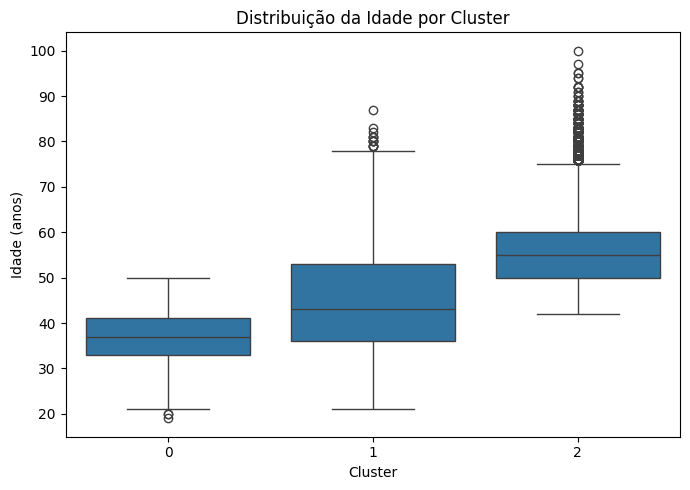

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,207374.0,37.271114,5.505426,19.0,33.0,37.0,41.0,50.0
1,40243.0,44.908928,11.011869,21.0,36.0,43.0,53.0,87.0
2,136857.0,55.658045,7.150438,42.0,50.0,55.0,60.0,100.0


In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df_clusters,
    x="cluster",
    y="NU_IDADE"
)
plt.title("Distribuição da Idade por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Idade (anos)")
plt.tight_layout()
plt.show()

df_clusters.groupby("cluster")["NU_IDADE"].describe()



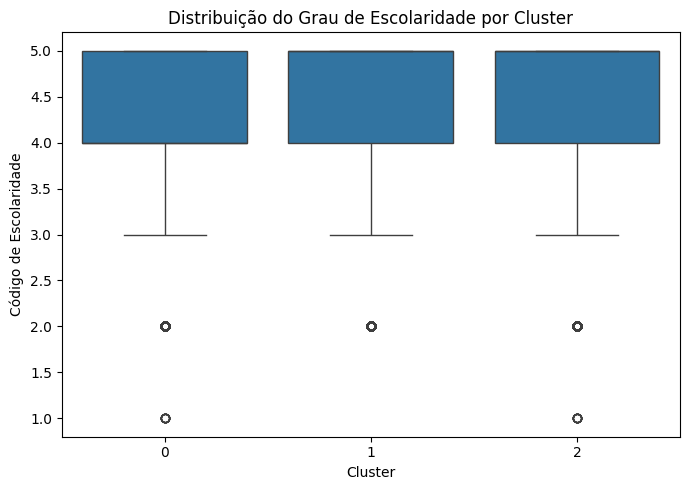

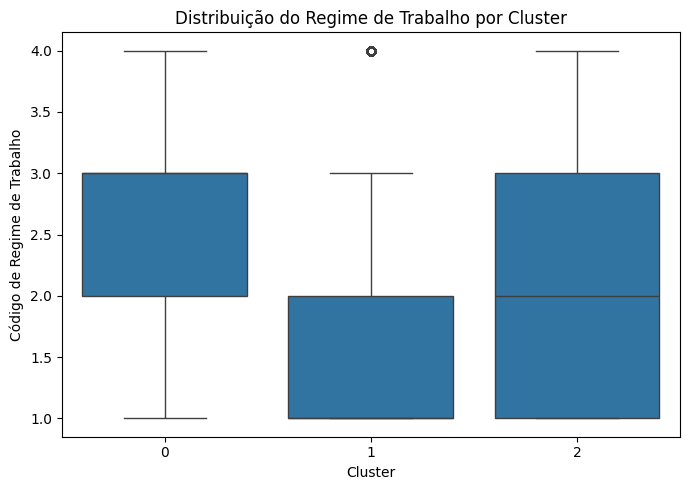

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df_clusters,
    x="cluster",
    y="TP_ESCOLARIDADE"
)
plt.title("Distribuição do Grau de Escolaridade por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Código de Escolaridade")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df_clusters,
    x="cluster",
    y="TP_REGIME_TRABALHO"
)
plt.title("Distribuição do Regime de Trabalho por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Código de Regime de Trabalho")
plt.tight_layout()
plt.show()


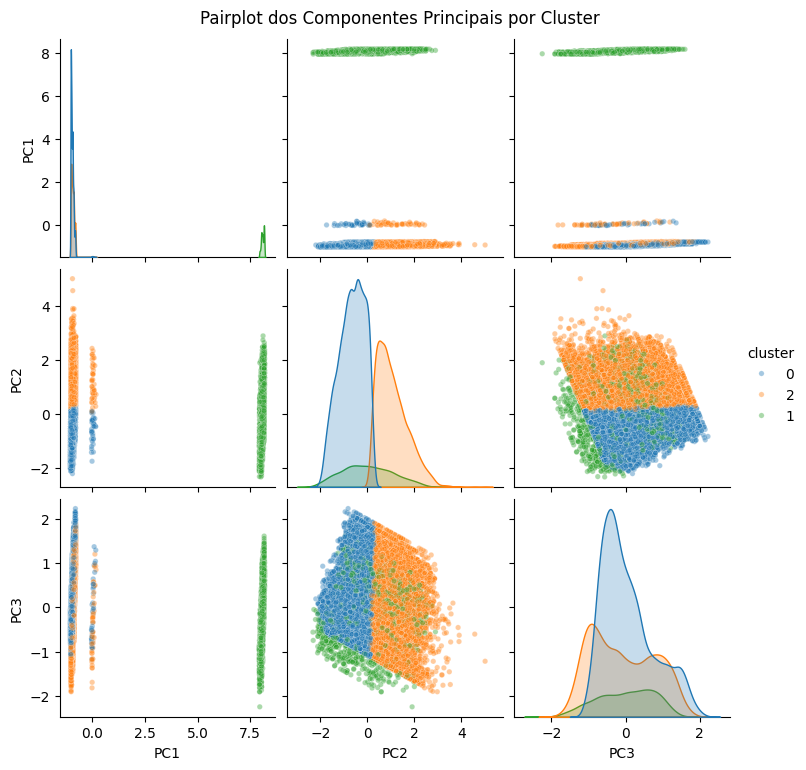

In [ ]:
from sklearn.decomposition import PCA

X_processed = modelo_kmeans_full["preprocess"].transform(df_sel)

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_processed)

df_pca3 = pd.DataFrame({
    "PC1": X_pca3[:, 0],
    "PC2": X_pca3[:, 1],
    "PC3": X_pca3[:, 2],
    "cluster": df_clusters["cluster"].astype(str)
})

# amostra para não explodir
n_amostra = 20000
if len(df_pca3) > n_amostra:
    df_pca3_sample = df_pca3.sample(n=n_amostra, random_state=42)
else:
    df_pca3_sample = df_pca3

sns.pairplot(
    df_pca3_sample,
    vars=["PC1", "PC2", "PC3"],
    hue="cluster",
    plot_kws={"alpha": 0.4, "s": 15}
)
plt.suptitle("Pairplot dos Componentes Principais por Cluster", y=1.02)
plt.show()


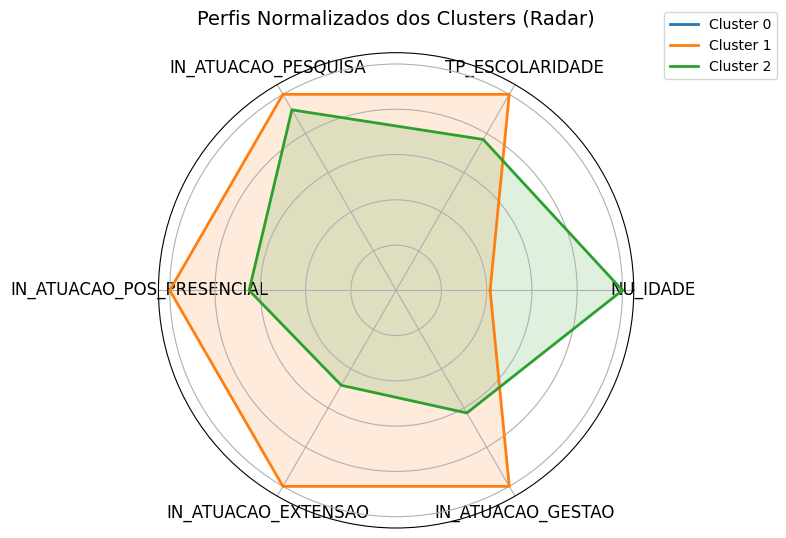

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Selecionar colunas do radar
cols_radar = [
    "NU_IDADE",
    "TP_ESCOLARIDADE",
    "IN_ATUACAO_PESQUISA",
    "IN_ATUACAO_POS_PRESENCIAL",
    "IN_ATUACAO_EXTENSAO",
    "IN_ATUACAO_GESTAO"
]

cluster_means = df_clusters.groupby("cluster")[cols_radar].mean()

# Normalização 0–1 por coluna
radar_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

labels = radar_norm.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # fechar círculo

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Desenha cada cluster
for c in radar_norm.index:
    values = radar_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {c}")
    ax.fill(angles, values, alpha=0.15)

# Ajustes visuais
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels([])

plt.title("Perfis Normalizados dos Clusters (Radar)", fontsize=14, pad=20)

# LEGENDA AJUSTADA PARA O LADO DIREITO (fora do gráfico)
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1.10))

plt.tight_layout()
plt.show()


In [ ]:
print(radar_norm)
print("\nCluster 0 normalizado:")
print(radar_norm.loc[0])


         NU_IDADE  TP_ESCOLARIDADE  IN_ATUACAO_PESQUISA  \
cluster                                                   
0        0.000000         0.000000             0.000000   
1        0.415394         1.000000             1.000000   
2        1.000000         0.769768             0.920788   

         IN_ATUACAO_POS_PRESENCIAL  IN_ATUACAO_EXTENSAO  IN_ATUACAO_GESTAO  
cluster                                                                     
0                         0.000000             0.000000           0.000000  
1                         1.000000             1.000000           1.000000  
2                         0.649292             0.484439           0.625563  

Cluster 0 normalizado:
NU_IDADE                     0.0
TP_ESCOLARIDADE              0.0
IN_ATUACAO_PESQUISA          0.0
IN_ATUACAO_POS_PRESENCIAL    0.0
IN_ATUACAO_EXTENSAO          0.0
IN_ATUACAO_GESTAO            0.0
Name: 0, dtype: float64


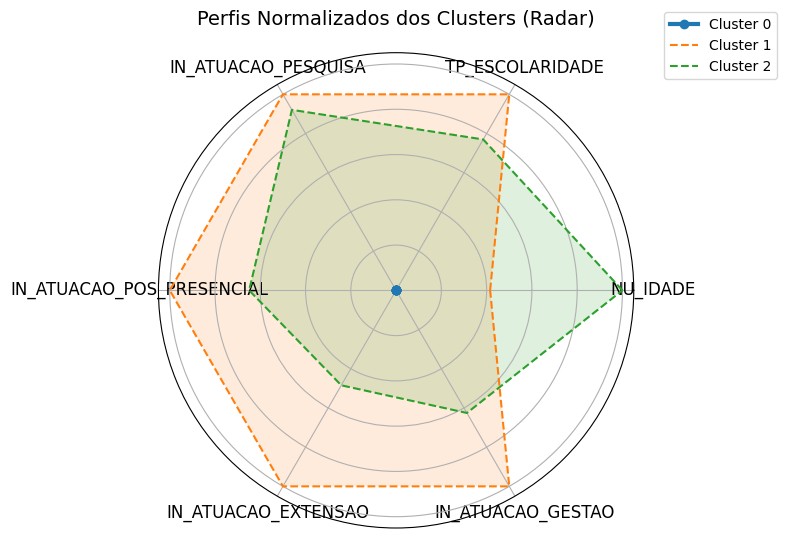

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Selecionar colunas do radar
cols_radar = [
    "NU_IDADE",
    "TP_ESCOLARIDADE",
    "IN_ATUACAO_PESQUISA",
    "IN_ATUACAO_POS_PRESENCIAL",
    "IN_ATUACAO_EXTENSAO",
    "IN_ATUACAO_GESTAO"
]

cluster_means = df_clusters.groupby("cluster")[cols_radar].mean()

# Normalização 0–1 por coluna
radar_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

labels = radar_norm.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # fechar círculo

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# DESENHO DOS CLUSTERS (aqui é onde mudamos)
for c in radar_norm.index:
    values = radar_norm.loc[c].tolist()
    values += values[:1]

    if c == 0:
        # Cluster 0: mais destacado
        ax.plot(angles, values, linewidth=3, marker='o', label="Cluster 0")
        ax.fill(angles, values, alpha=0.3)
    else:
        # Demais clusters: mais "leves"
        ax.plot(angles, values, linewidth=1.5, linestyle='--', label=f"Cluster {c}")
        ax.fill(angles, values, alpha=0.15)

# Ajustes visuais
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels([])

plt.title("Perfis Normalizados dos Clusters (Radar)", fontsize=14, pad=20)

# LEGENDA AJUSTADA PARA O LADO DIREITO (fora do gráfico)
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1.10))

plt.tight_layout()
plt.show()


In [ ]:
#AGGLOMERATIVE CLUSTERING

# 1. Amostrar 10.000 docentes
df_sample_10k = df_sel.sample(n=10000, random_state=42)
idx_labels_10k = df_sample_10k.index

# Converter rótulos do índice em posições da matriz X_prepared
idx_pos_10k = df_sel.index.get_indexer(idx_labels_10k)

X_sample_10k = X_prepared[idx_pos_10k, :]
X_sample_10k.shape  # deve ser (10000, 29)


(10000, 29)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg_10k = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_agg_10k = agg_10k.fit_predict(X_sample_10k)
len(labels_agg_10k)


10000

In [ ]:
from sklearn.metrics import silhouette_score

sil_agg_10k = silhouette_score(X_sample_10k, labels_agg_10k)
sil_agg_10k


np.float64(0.17024590182537028)

In [ ]:
# Se ainda não tiver associado os rótulos ao dataframe:
df_sample_10k["cluster_agg"] = labels_agg_10k

# Contagem absoluta por cluster
cluster_counts_agg = df_sample_10k["cluster_agg"].value_counts().sort_index()
print(cluster_counts_agg)

# Opcional: contagem relativa (percentual)
cluster_percent_agg = (cluster_counts_agg / len(df_sample_10k)) * 100
print(cluster_percent_agg.round(2))


cluster_agg
0    4933
1    1051
2    4016
Name: count, dtype: int64
cluster_agg
0    49.33
1    10.51
2    40.16
Name: count, dtype: float64


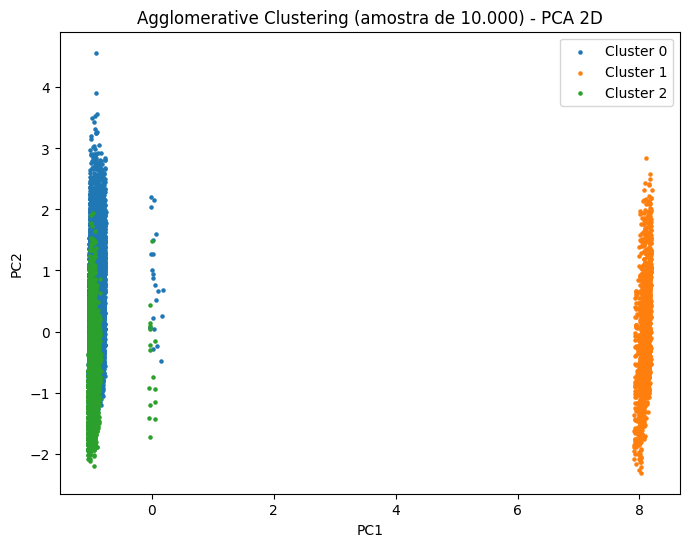

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_10k = PCA(n_components=2, random_state=42)
X_pca_10k = pca_10k.fit_transform(X_sample_10k)

plt.figure(figsize=(8, 6))
for c in range(3):
    mask = labels_agg_10k == c
    plt.scatter(
        X_pca_10k[mask, 0],
        X_pca_10k[mask, 1],
        s=5,
        label=f"Cluster {c}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering (amostra de 10.000) - PCA 2D")
plt.legend()
plt.show()


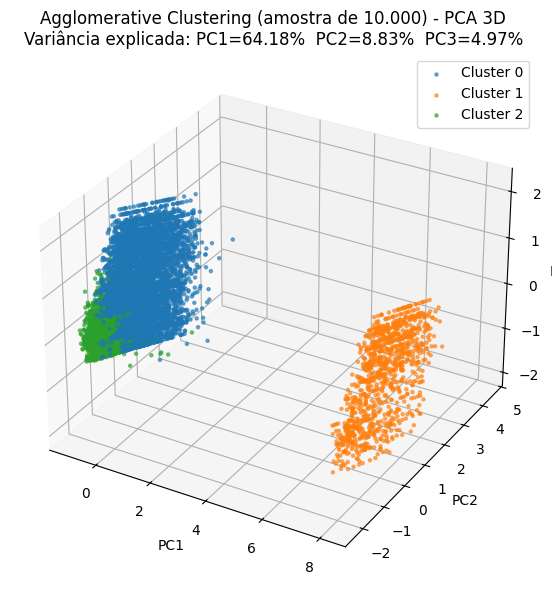

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessário para 3D
from sklearn.decomposition import PCA

# --- Se já tiver X_sample_agg e labels_agg, pode começar daqui ---

# PCA em 3 componentes
pca_agg_3d = PCA(n_components=3, random_state=42)
X_agg_pca3 = pca_agg_3d.fit_transform(X_sample_10k)

var_ratio = pca_agg_3d.explained_variance_ratio_ * 100  # em %

# Plot 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

cores = ['tab:blue', 'tab:orange', 'tab:green']

for c, cor in zip(np.unique(labels_agg_10k), cores):
    ax.scatter(
        X_agg_pca3[labels_agg_10k == c, 0],
        X_agg_pca3[labels_agg_10k == c, 1],
        X_agg_pca3[labels_agg_10k == c, 2],
        s=5,
        alpha=0.6,
        label=f"Cluster {c}",
        c=cor
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title(
    f"Agglomerative Clustering (amostra de 10.000) - PCA 3D\n"
    f"Variância explicada: PC1={var_ratio[0]:.2f}%  PC2={var_ratio[1]:.2f}%  PC3={var_ratio[2]:.2f}%"
)

ax.legend()
plt.tight_layout()
plt.show()